# Ejercicio 7 - Construccion de indicadores y visualizacion

## 0. Configuracion

In [1]:
import os
import subprocess
import sys
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ / "scripts"))

import indicadores
from run_sql import cargar_consultas

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 250)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
TIPOS = ["yellow", "green"]
COLORES_ANIO = {2024: "#9AA5B1", 2025: "#4C72B0", 2026: "#DD8452"}

CONSULTAS = cargar_consultas(Path("sql/07_indicadores.sql"))
con = None   # conexion de solo lectura a data/processed/indicadores.duckdb (se abre despues de construirla)


def q(sql):
    # Ejecuta la consulta en DuckDB y devuelve el resultado como DataFrame.
    inicio = time.perf_counter()
    df = con.sql(sql).df()
    print(f"{len(df)} filas | {time.perf_counter() - inicio:.2f} s")
    return df


def indicador(nombre, mostrar_sql=True):
    # Muestra la consulta del indicador (sql/07_indicadores.sql) y devuelve su tabla.
    descripcion, sql = CONSULTAS[nombre]
    if mostrar_sql:
        print(descripcion, "\n")
        print(sql, "\n")
    return q(f"SELECT * FROM {nombre}")


def por_anio(df, x, y, titulo, etiqueta_y):
    # Un grafico por tipo de taxi con una linea por anio.
    fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6))
    for eje, tipo in zip(ejes, TIPOS):
        for anio, d in df[df.tipo == tipo].groupby("anio"):
            eje.plot(d[x], d[y], marker="o", ms=3, color=COLORES_ANIO.get(anio), label=str(anio))
        eje.set_title(f"{tipo}: {titulo}")
        eje.set_xlabel(x)
        eje.set_ylabel(etiqueta_y)
        eje.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}" if abs(v) >= 100 else f"{v:,.1f}")
    ejes[0].legend()
    plt.tight_layout()
    plt.show()


def en_el_tiempo(df, columnas, titulo):
    # Un grafico por tipo de taxi con la evolucion mensual de varias columnas.
    fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6))
    for eje, tipo in zip(ejes, TIPOS):
        d = df[df.tipo == tipo]
        for columna in columnas:
            eje.plot(d.fecha, d[columna], marker="o", ms=3, label=columna)
        eje.set_title(f"{tipo}: {titulo}")
        eje.tick_params(axis="x", rotation=45)
    ejes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def promedio_anual(df, columnas):
    # Promedio de los valores mensuales de cada anio.
    return df.groupby(["tipo", "anio"], sort=False)[columnas].mean().round(2)


print("DuckDB", duckdb.__version__)

DuckDB 1.5.5


## 7.1 y 7.2 Preguntas e indicadores

Cada pregunta se responde con un indicador. Todos se separan por tipo de taxi y por anio, porque en el Ejercicio 5 se vio que mezclar anios da resultados enganiosos.

| # | Pregunta | Indicador (tabla) | Grafico en Metabase |
|---|---|---|---|
| P1 | ¿Cuantos viajes hay por dia en cada mes y como cambia entre anios? | `i01_demanda_mensual`: viajes promedio por dia de cada mes | Lineas, una por anio |
| P2 | ¿Cuanto pesa cada tipo de taxi en viajes e ingresos? | `i02_resumen_anual`: viajes, % del anio, viajes e ingreso por dia, % de aeropuerto | Tabla |
| P3 | ¿A que horas del dia se concentran los viajes? | `i03_demanda_por_hora`: % de los viajes del anio en cada hora | Lineas, una por anio |
| P4 | ¿A que horas hay mas congestion? | `i04_velocidad_por_hora`: velocidad mediana (mph) por hora | Lineas, una por anio |
| P5 | ¿Como es el viaje tipico y cambia con el tiempo? | `i05_viaje_tipico`: distancia y duracion medianas por mes | Lineas en el tiempo |
| P6 | ¿Cuanto cuesta un viaje y que parte son recargos? | `i06_costo_y_recargos`: total mediano, recargo promedio, % del total en recargos, % con cargo CBD | Lineas en el tiempo |
| P7 | ¿Como pagan los pasajeros? | `i07_formas_pago`: % tarjeta, efectivo, Flex Fare y otros por mes | Barras apiladas |
| P8 | ¿Cuanta propina se deja? | `i08_propinas`: propina mediana con tarjeta (% de la tarifa) y % sin propina | Lineas en el tiempo |
| P9 | ¿De donde salen los viajes? | `i09_origen_borough`: % de viajes por borough de origen | Barras por anio |
| P10 | ¿Que tan confiables son los datos? | `i10_calidad_datos`: % de registros descartados por la limpieza cada mes | Barras en el tiempo |

## 7.3 Construccion de las consultas

Las consultas estan en `sql/07_indicadores.sql`. `scripts/indicadores.py` las ejecuta sobre los Parquet y guarda cada indicador como una tabla pequenia en `data/processed/indicadores.duckdb`. Asi el tablero no tiene que leer los Parquet cada vez que se abre, que fue la recomendacion del Ejercicio 6.

In [2]:
inicio = time.perf_counter()
resumen = pd.DataFrame(indicadores.construir(), columns=["tabla", "filas", "segundos"])
print(f"Base construida en {time.perf_counter() - inicio:.1f} s ({indicadores.BASE.stat().st_size / 1e6:.1f} MB)")
display(resumen)

con = duckdb.connect(str(indicadores.BASE), read_only=True)

Base construida en 79.6 s (3.2 MB)


,tabla,filas,segundos
0,zonas,265,0.46
1,i01_demanda_mensual,64,6.29
2,i02_resumen_anual,6,13.73
3,i03_demanda_por_hora,144,5.84
4,i04_velocidad_por_hora,144,7.13
5,i05_viaje_tipico,64,9.68
6,i06_costo_y_recargos,64,7.87
7,i07_formas_pago,64,6.38
8,i08_propinas,64,6.31
9,i09_origen_borough,46,7.14


## 7.4 Indicadores

### I1 - Viajes por dia en cada mes

P1. Cuantos viajes hay por dia en cada mes y como cambia entre anios. Se usa el promedio por dia para que los meses de distinta duracion sean comparables. 

SELECT tipo, anio, mes,
       make_date(anio, mes, 1)                               AS fecha,
       count(*)                                              AS viajes,
       count(DISTINCT pickup::DATE)                          AS dias,
       round(count(*) / count(DISTINCT pickup::DATE))        AS viajes_por_dia
FROM viajes_limpios
GROUP BY ALL
ORDER BY tipo DESC, anio, mes 

64 filas | 0.02 s


tipo     yellow                          green                  
anio       2024       2025       2026     2024     2025     2026
mes                                                             
1     92,234.00 104,585.00 113,087.00 1,701.00 1,444.00 1,235.00
2     99,704.00 117,734.00 114,324.00 1,721.00 1,535.00 1,263.00
3    110,583.00 123,054.00 121,014.00 1,728.00 1,523.00 1,356.00
4    113,414.00 121,989.00 122,115.00 1,745.00 1,591.00 1,397.00
5    116,296.00 131,569.00 125,823.00 1,833.00 1,648.00 1,375.00
6    113,866.00 128,544.00 121,155.00 1,703.00 1,539.00 1,399.00
7     95,550.00 112,349.00 107,596.00 1,547.00 1,478.00 1,256.00
8     92,108.00 102,218.00 101,728.00 1,549.00 1,416.00 1,235.00
9    115,701.00 127,489.00        NaN 1,688.00 1,555.00      NaN
10   118,349.00 126,783.00        NaN 1,696.00 1,516.00      NaN
11   116,578.00 121,044.00        NaN 1,619.00 1,487.00      NaN
12   113,086.00 130,195.00        NaN 1,614.00 1,477.00      NaN

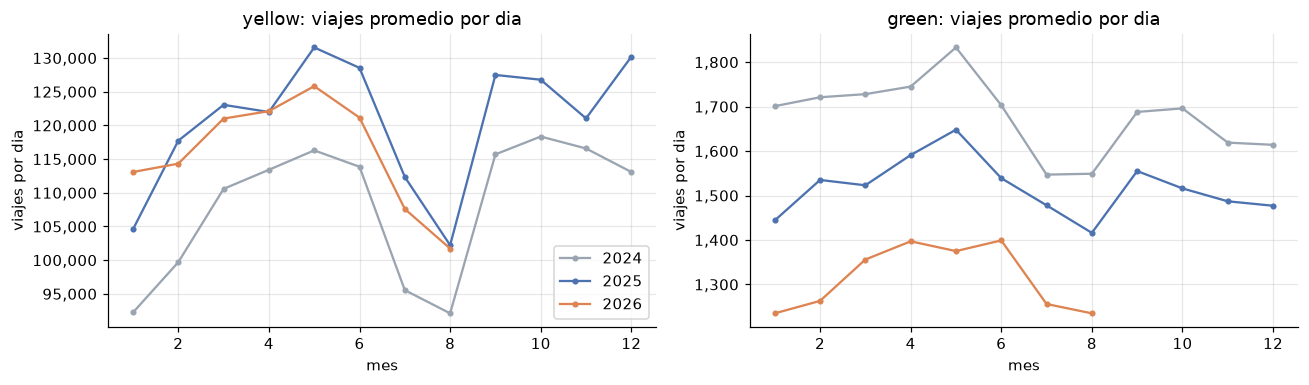

In [3]:
i01 = indicador("i01_demanda_mensual")
display(i01.pivot_table(index="mes", columns=["tipo", "anio"], values="viajes_por_dia")[TIPOS])
por_anio(i01, "mes", "viajes_por_dia", "viajes promedio por dia", "viajes por dia")

### I2 - Resumen por anio

In [4]:
i02 = indicador("i02_resumen_anual")
i02

P2. Cuanto pesa cada tipo de taxi en viajes e ingresos y que parte son viajes de aeropuerto. Los anios no tienen la misma cantidad de meses, por eso se comparan valores por dia. 

SELECT tipo, anio,
       count(DISTINCT mes)                                                    AS meses,
       count(*)                                                               AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY anio), 2)    AS pct_viajes_del_anio,
       round(count(*) / count(DISTINCT pickup::DATE))                         AS viajes_por_dia,
       round(sum(total_amount) / count(DISTINCT pickup::DATE))                AS ingreso_por_dia_usd,
       round(sum(total_amount) / 1e6, 1)                                      AS ingreso_total_musd,
       round(100.0 * avg((coalesce(ratecode_id, 0) IN (2, 3)
                          OR coalesce(airport_fee, 0) > 0
                          OR pu_zona IN (1, 132, 138) OR do_zona IN (1, 132, 138))::INT), 2) AS pct_aer

,tipo,anio,meses,viajes,pct_viajes_del_anio,viajes_por_dia,ingreso_por_dia_usd,ingreso_total_musd,pct_aeropuerto
0,yellow,2024,12,39562556,98.47,"108,094.00","3,091,076.00","1,131.30",10.53
1,yellow,2025,12,44021895,98.76,"120,608.00","3,476,222.00","1,268.80",9.15
2,yellow,2026,8,28145839,98.88,"115,826.00","3,494,819.00",849.20,8.39
3,green,2024,12,614284,1.53,"1,678.00","40,392.00",14.80,4.26
4,green,2025,12,553720,1.24,"1,517.00","38,091.00",13.90,3.77
5,green,2026,8,319435,1.12,"1,315.00","33,293.00",8.10,3.39


### I3 - Porcentaje de viajes por hora

P3. A que horas del dia se concentran los viajes. 

SELECT tipo, anio, hour(pickup) AS hora,
       count(*)                                                                 AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo, anio), 2) AS pct_viajes
FROM viajes_limpios
GROUP BY tipo, anio, hora
ORDER BY tipo DESC, anio, hora 

144 filas | 0.01 s


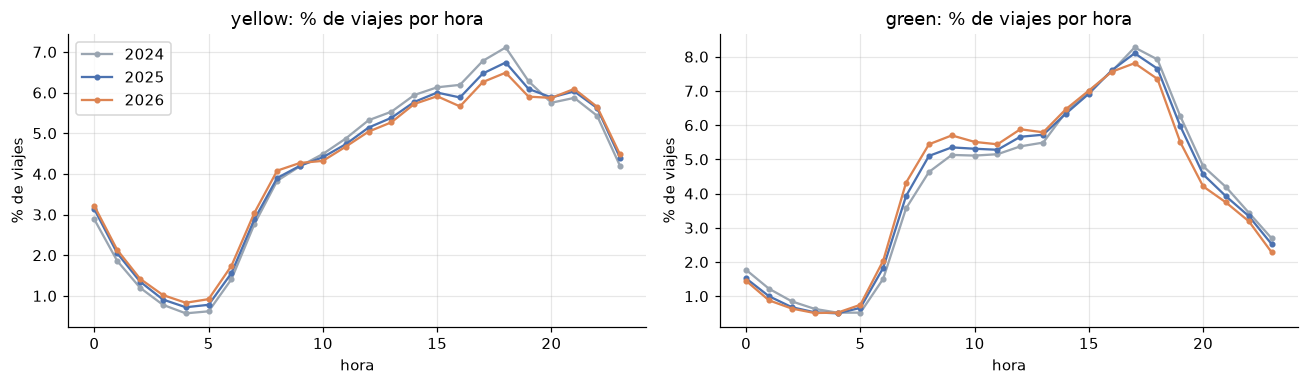

In [5]:
i03 = indicador("i03_demanda_por_hora")
por_anio(i03, "hora", "pct_viajes", "% de viajes por hora", "% de viajes")

### I4 - Velocidad mediana por hora

P4. A que horas hay mas congestion (velocidad mediana de los viajes). 

SELECT tipo, anio, hour(pickup) AS hora,
       round(median(trip_distance / (duracion_min / 60)), 1) AS velocidad_mediana_mph
FROM viajes_limpios
GROUP BY ALL
ORDER BY tipo DESC, anio, hora 

144 filas | 0.00 s


hora           0     1     2     3     4     5     6     7    8     9     10    11    12   13   14   15   16   17    18    19    20    21    22    23
tipo   anio                                                                                                                                          
yellow 2024 11.80 12.10 12.60 13.60 15.50 16.50 14.00 11.20 9.30  8.90  8.70  8.20  8.20 8.20 8.10 8.00 8.20 8.20  8.50  9.20  9.90 10.30 10.70 11.30
       2025 12.10 12.40 12.90 13.90 15.60 16.40 14.10 11.30 9.40  9.10  8.80  8.30  8.30 8.30 8.20 8.00 8.20 8.20  8.50  9.10 10.00 10.40 10.70 11.50
       2026 11.80 12.30 12.90 13.80 15.40 16.00 13.80 11.10 9.30  8.90  8.60  8.10  8.10 8.10 8.00 7.90 8.00 8.00  8.30  8.90  9.80 10.10 10.50 11.20
green  2024 12.50 12.70 13.10 14.10 15.10 16.10 12.80 10.40 9.60 10.20 10.30 10.10 10.00 9.90 9.30 9.20 9.40 9.50 10.00 10.70 11.10 11.70 12.30 12.40
       2025 12.70 12.90 13.90 14.60 16.00 16.80 12.70 10.30 9.50 10.00 10.00  9.90  9.90 9.70 9.30 9.20 9.30 9.50 10.00 10.70 11.10 11.80 12.30 12.50
       2026 12.10 12.40 14.00 14.60 16.40 16.10 12.80 10.50 9.50  9.90 10.10  9.80  9.80 9.60 9.10 9.00 9.20 9.30  9.70 10.50 10.80 11.40 12.10 12.20

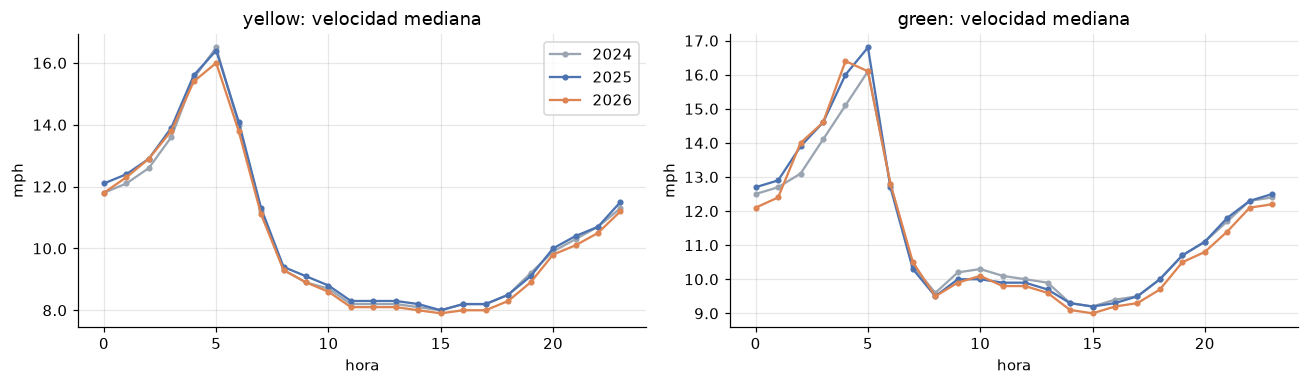

In [6]:
i04 = indicador("i04_velocidad_por_hora")
display(i04.pivot_table(index=["tipo", "anio"], columns="hora", values="velocidad_mediana_mph").loc[TIPOS])
por_anio(i04, "hora", "velocidad_mediana_mph", "velocidad mediana", "mph")

### I5 - Viaje tipico

P5. Como es el viaje tipico (distancia y duracion medianas) y si cambia con el tiempo. 

SELECT tipo, anio, mes,
       make_date(anio, mes, 1)              AS fecha,
       round(median(trip_distance), 2)      AS distancia_mediana_mi,
       round(median(duracion_min), 1)       AS duracion_mediana_min
FROM viajes_limpios
GROUP BY ALL
ORDER BY tipo DESC, anio, mes 

64 filas | 0.01 s


distancia_mediana_mi  duracion_mediana_min
tipo   anio                                            
yellow 2024                  1.79                 13.12
       2025                  1.89                 13.58
       2026                  1.94                 14.16
green  2024                  1.99                 12.08
       2025                  2.09                 12.82
       2026                  2.16                 13.44

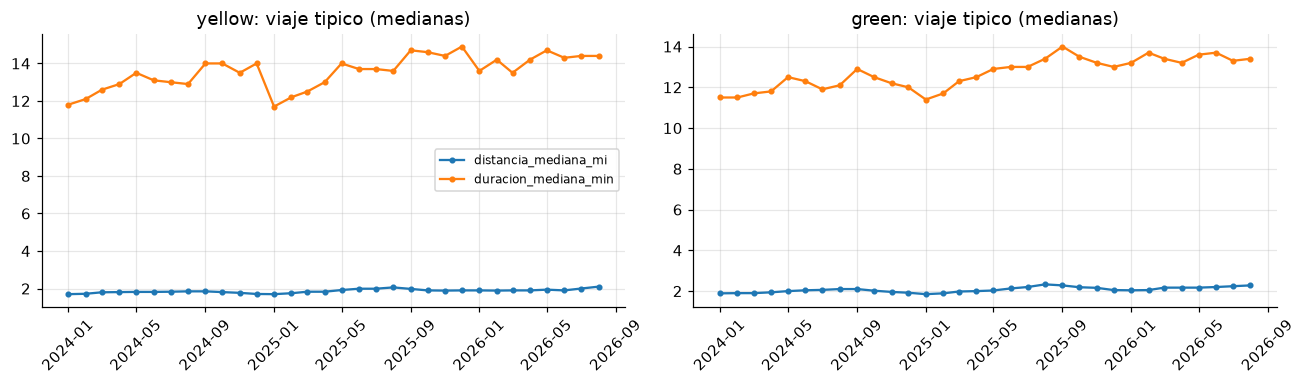

In [7]:
i05 = indicador("i05_viaje_tipico")
display(promedio_anual(i05, ["distancia_mediana_mi", "duracion_mediana_min"]))
en_el_tiempo(i05, ["distancia_mediana_mi", "duracion_mediana_min"], "viaje tipico (medianas)")

### I6 - Costo del viaje y peso de los recargos

P6. Cuanto cuesta un viaje y que parte del cobro son recargos (incluye el cargo CBD de 2025). Recargos = total - tarifa - propina - peajes. 

SELECT tipo, anio, mes,
       make_date(anio, mes, 1)                                                    AS fecha,
       round(median(total_amount), 2)                                             AS total_mediano_usd,
       round(avg(total_amount - fare_amount - tip_amount - tolls_amount), 2)      AS recargos_promedio_usd,
       round(100 * sum(total_amount - fare_amount - tip_amount - tolls_amount)
                 / sum(total_amount), 1)                                          AS pct_del_total_en_recargos,
       round(100.0 * avg((coalesce(cbd_congestion_fee, 0) > 0)::INT), 1)          AS pct_con_cargo_cbd
FROM viajes_limpios
WHERE total_amount > 0
GROUP BY ALL
ORDER BY tipo DESC, anio, mes 

64 filas | 0.02 s


total_mediano_usd  recargos_promedio_usd  pct_del_total_en_recargos  pct_con_cargo_cbd
tipo   anio                                                                                        
yellow 2024              21.18                   4.87                      17.07               0.00
       2025              22.07                   5.24                      18.27              73.08
       2026              23.61                   5.52                      18.31              72.66
green  2024              19.33                   3.21                      13.35               0.00
       2025              20.14                   4.31                      17.09               9.68
       2026              20.58                   5.77                      22.81               8.55

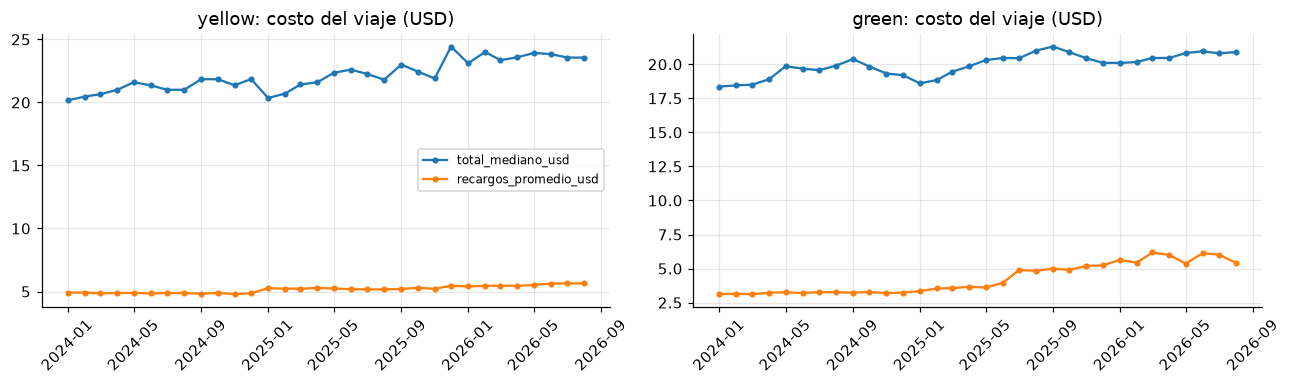

In [8]:
i06 = indicador("i06_costo_y_recargos")
display(promedio_anual(i06, ["total_mediano_usd", "recargos_promedio_usd", "pct_del_total_en_recargos", "pct_con_cargo_cbd"]))
en_el_tiempo(i06, ["total_mediano_usd", "recargos_promedio_usd"], "costo del viaje (USD)")

### I7 - Formas de pago

P7. Como pagan los pasajeros y si eso cambia con el tiempo. payment_type 0 o NULL son viajes Flex Fare / sin dato (ver Ejercicio 4). 

SELECT tipo, anio, mes,
       make_date(anio, mes, 1)                                          AS fecha,
       round(100.0 * avg((coalesce(payment_type, 0) = 1)::INT), 1)      AS pct_tarjeta,
       round(100.0 * avg((coalesce(payment_type, 0) = 2)::INT), 1)      AS pct_efectivo,
       round(100.0 * avg((coalesce(payment_type, 0) = 0)::INT), 1)      AS pct_flex_fare,
       round(100.0 * avg((coalesce(payment_type, 0) >= 3)::INT), 1)     AS pct_otros
FROM viajes_limpios
GROUP BY ALL
ORDER BY tipo DESC, anio, mes 

64 filas | 0.01 s


pct_tarjeta  pct_efectivo  pct_flex_fare  pct_otros
tipo   anio                                                     
yellow 2024        76.21         13.30           9.16       1.31
       2025        68.82          9.72          19.94       1.53
       2026        65.24          9.00          25.16       0.61
green  2024        68.93         26.92           3.81       0.31
       2025        69.22         22.15           8.35       0.27
       2026        65.59         19.30          14.91       0.22

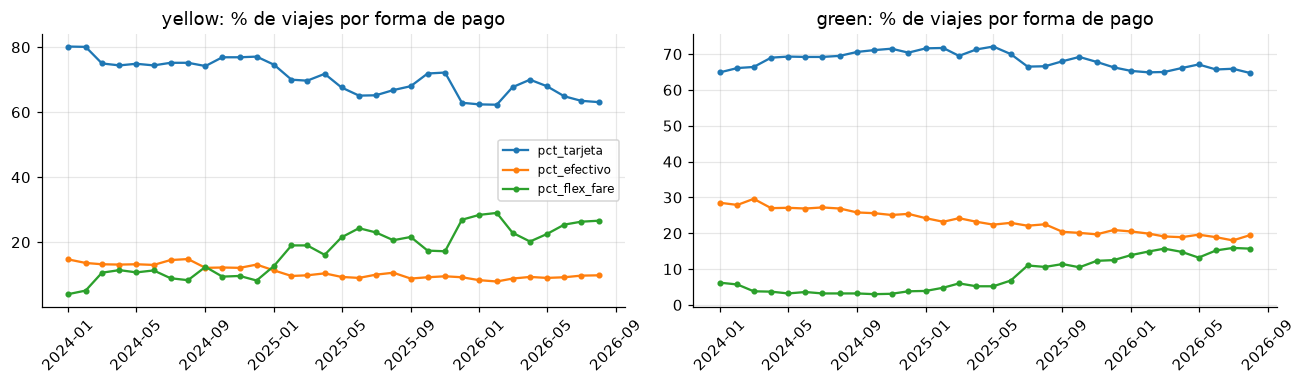

In [9]:
i07 = indicador("i07_formas_pago")
display(promedio_anual(i07, ["pct_tarjeta", "pct_efectivo", "pct_flex_fare", "pct_otros"]))
en_el_tiempo(i07, ["pct_tarjeta", "pct_efectivo", "pct_flex_fare"], "% de viajes por forma de pago")

### I8 - Propinas con tarjeta

P8. Cuanta propina se deja con tarjeta (las propinas en efectivo no se registran). 

SELECT tipo, anio, mes,
       make_date(anio, mes, 1)                                          AS fecha,
       round(100 * median(tip_amount / fare_amount), 1)                 AS propina_mediana_pct,
       round(100.0 * avg((tip_amount = 0)::INT), 1)                     AS pct_sin_propina
FROM viajes_limpios
WHERE payment_type = 1 AND fare_amount > 0
GROUP BY ALL
ORDER BY tipo DESC, anio, mes 

64 filas | 0.00 s


propina_mediana_pct  pct_sin_propina
tipo   anio                                      
yellow 2024                25.78             5.60
       2025                26.44             7.25
       2026                26.45             8.82
green  2024                23.44             8.50
       2025                23.48             8.36
       2026                23.61             8.31

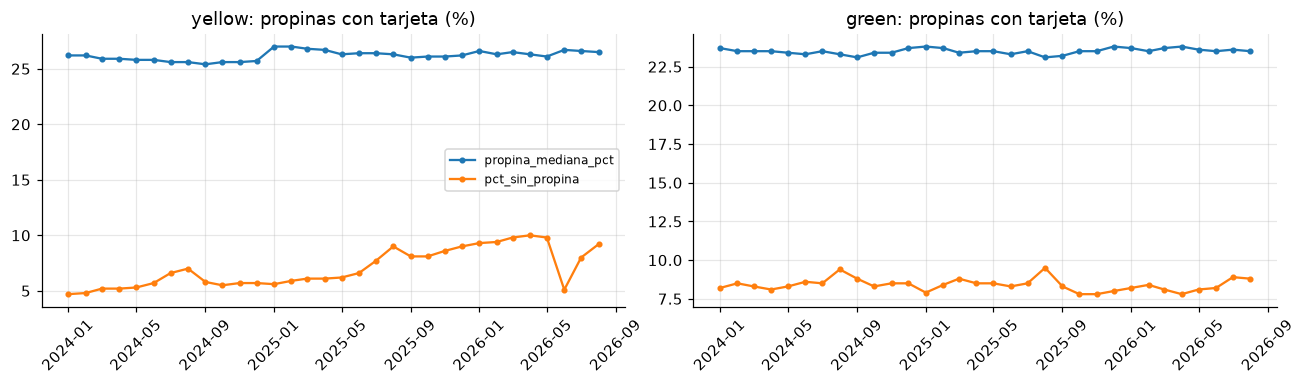

In [10]:
i08 = indicador("i08_propinas")
display(promedio_anual(i08, ["propina_mediana_pct", "pct_sin_propina"]))
en_el_tiempo(i08, ["propina_mediana_pct", "pct_sin_propina"], "propinas con tarjeta (%)")

### I9 - Origen de los viajes por borough

P9. De que borough salen los viajes. 

SELECT v.tipo, v.anio, coalesce(z.borough, 'Unknown') AS borough,
       count(*)                                                                     AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY v.tipo, v.anio), 2) AS pct_viajes
FROM viajes_limpios v
LEFT JOIN zonas z ON v.pu_zona = z.zona
GROUP BY v.tipo, v.anio, borough
ORDER BY v.tipo DESC, v.anio, viajes DESC 

46 filas | 0.01 s


tipo          yellow             green            
anio            2024  2025  2026  2024  2025  2026
borough                                           
Manhattan      88.90 86.35 86.74 61.04 61.67 59.83
Queens          9.12  9.35  8.75 24.39 22.20 21.79
Brooklyn        1.39  3.33  3.60 13.41 14.39 15.75
Bronx           0.29  0.77  0.77  1.06  1.63  2.47
Unknown         0.28  0.17  0.10  0.05  0.06  0.09
N/A             0.02  0.01  0.02  0.04  0.04  0.05
Staten Island   0.00  0.01  0.01  0.00  0.01  0.02
EWR             0.00  0.00  0.00  0.00  0.00  0.00

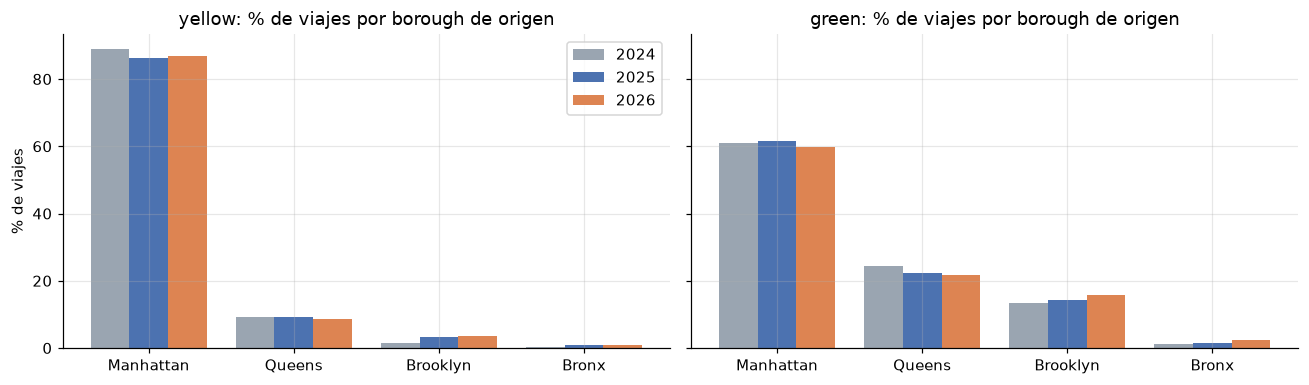

In [11]:
i09 = indicador("i09_origen_borough")
tabla = i09.pivot_table(index="borough", columns=["tipo", "anio"], values="pct_viajes").fillna(0)[TIPOS]
tabla = tabla.sort_values(("yellow", tabla["yellow"].columns[-1]), ascending=False)
display(tabla)

principales = ["Manhattan", "Queens", "Brooklyn", "Bronx"]
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for eje, tipo in zip(ejes, TIPOS):
    t = tabla.loc[principales, tipo]
    ancho = 0.8 / len(t.columns)
    for i, anio in enumerate(t.columns):
        eje.bar([j + i * ancho for j in range(len(principales))], t[anio], width=ancho,
                color=COLORES_ANIO.get(anio), label=str(anio))
    eje.set_xticks([j + ancho for j in range(len(principales))], principales)
    eje.set_title(f"{tipo}: % de viajes por borough de origen")
ejes[0].set_ylabel("% de viajes")
ejes[0].legend()
plt.tight_layout()
plt.show()

### I10 - Registros descartados por la limpieza

P10. Que parte de los registros se descarta por la regla de limpieza en cada mes. 

SELECT t.tipo, t.anio, t.mes,
       make_date(t.anio, t.mes, 1)                                  AS fecha,
       t.registros,
       l.registros                                                  AS registros_limpios,
       round(100.0 * (t.registros - l.registros) / t.registros, 2)  AS pct_descartado
FROM (SELECT tipo, anio, mes, count(*) AS registros FROM viajes GROUP BY ALL) t
JOIN (SELECT tipo, anio, mes, count(*) AS registros FROM viajes_limpios GROUP BY ALL) l
  USING (tipo, anio, mes)
ORDER BY t.tipo DESC, t.anio, t.mes 

64 filas | 0.01 s


registros  registros_limpios  pct_descartado
tipo   anio                                              
yellow 2024   41169720           39562556            3.90
       2025   48722602           44021895            9.65
       2026   29703355           28145839            5.24
green  2024     660218             614284            6.96
       2025     591375             553720            6.37
       2026     337114             319435            5.24

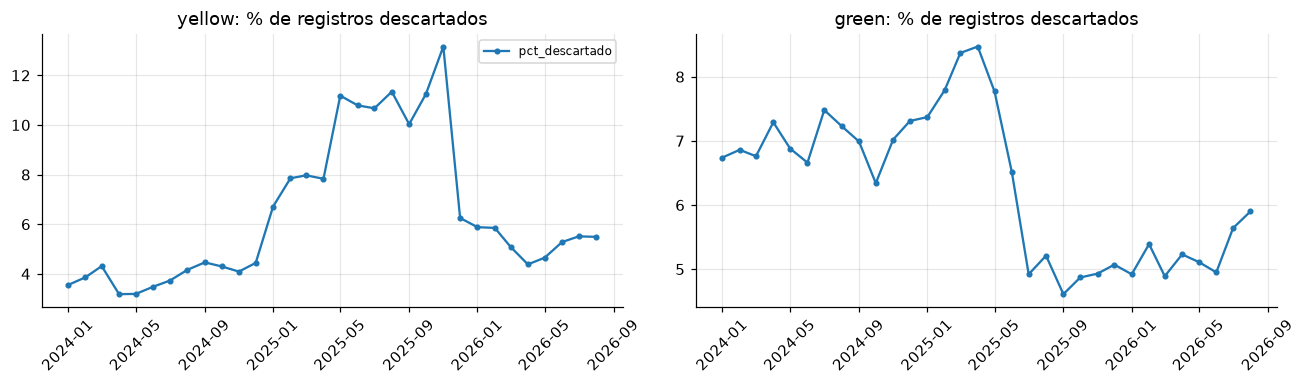

In [12]:
i10 = indicador("i10_calidad_datos")
resumen_calidad = i10.groupby(["tipo", "anio"], sort=False)[["registros", "registros_limpios"]].sum()
resumen_calidad["pct_descartado"] = 100 * (1 - resumen_calidad.registros_limpios / resumen_calidad.registros)
display(resumen_calidad)
en_el_tiempo(i10, ["pct_descartado"], "% de registros descartados")

## 7.5 Tablero en Metabase

`scripts/tablero_metabase.py` crea el tablero en Metabase a partir de las tablas de `data/processed/indicadores.duckdb`, que se conecta en modo solo lectura. Tiene una tarjeta por indicador y un filtro **Tipo de taxi** que cambia todas las tarjetas a la vez entre `yellow` y `green`. La descripcion de cada tarjeta incluye la pregunta que responde y su interpretacion.

Si el tablero ya existe, el script lo reemplaza. Para verlo se entra a <http://localhost:3001> con el usuario que imprime la celda (por defecto `admin@lab8.local` / `Lab8-DuckDB-2026`). La captura del tablero esta en `docs/tablero_metabase.png`.

In [13]:
proceso = subprocess.run([sys.executable, "scripts/tablero_metabase.py"], capture_output=True, text=True)
print(proceso.stdout or proceso.stderr)

  I1 Viajes por dia en cada mes                   32 filas
  I2 Resumen por anio                              3 filas
  I3 Porcentaje de viajes por hora                72 filas
  I4 Velocidad mediana por hora                   72 filas
  I5 Viaje tipico (medianas)                      32 filas
  I6 Costo del viaje y peso de los recargos       32 filas
  I7 Formas de pago (% de viajes)                 32 filas
  I8 Propinas con tarjeta                         32 filas
  I9 Origen de los viajes por borough             15 filas
  I10 Registros descartados por la limpieza       32 filas
Tablero listo: http://localhost:3001/dashboard/5 (usuario admin@lab8.local)



## Respuestas

7.1 ¿Que preguntas se plantearon?

Se plantearon diez preguntas, que estan en la tabla de la seccion 7.1 y 7.2. Salen de lo que se vio en el Ejercicio 4. Cubren la demanda por mes y por hora, el peso de cada tipo de taxi, la congestion, el viaje tipico, el costo y los recargos, la forma de pago, las propinas, el origen de los viajes y la calidad de los datos.

7.2 ¿Como se disenaron los indicadores?

Cada pregunta tiene un indicador, en total diez. Todos se calculan por tipo de taxi y por anio, porque en el Ejercicio 5 se vio que mezclar anios da resultados que enganian. Se usan valores por dia en lugar de totales, porque los meses y los anios no tienen la misma cantidad de dias (2026 solo tiene 8 meses). Para distancia, duracion, total y propina se usa la mediana y no el promedio, porque hay valores extremos. Todos los indicadores, menos el de calidad, usan los viajes limpios con la misma regla del Ejercicio 4.

7.3 ¿Como se construyeron las consultas?

Las consultas estan en `sql/07_indicadores.sql`, con el mismo formato `-- name:` del Ejercicio 3. El script `scripts/indicadores.py` crea las vistas `viajes` y `viajes_limpios` sobre los Parquet y guarda el resultado de cada consulta como una tabla en `data/processed/indicadores.duckdb`. La base completa pesa unos 3 MB y se construye en poco mas de un minuto. Es lo que se recomendo en el Ejercicio 6: el tablero lee tablas pequenias ya calculadas en lugar de recorrer mas de 100 millones de filas cada vez que se abre.

7.4 ¿Que visualizaciones se usaron?

Para lo que cambia mes a mes o por hora se usan lineas, con una linea por anio cuando interesa comparar la misma temporada. Para las formas de pago se usan barras apiladas, porque suman el 100 %. Los boroughs, que son categorias, van en barras agrupadas por anio. El resumen anual va en una tabla porque mezcla medidas con escalas distintas. En el notebook se dibujan los mismos indicadores con matplotlib para revisarlos.

7.5 ¿Como esta organizado el tablero?

El tablero de Metabase "Taxis de Nueva York 2024-2026" tiene un encabezado y una tarjeta por indicador, dos por fila, con el resumen anual a lo ancho. Arriba tiene el filtro "Tipo de taxi", que cambia todas las tarjetas a la vez entre amarillos y verdes. Esto es necesario porque los verdes tienen unas 90 veces menos viajes y, si se dibujan juntos, su linea queda plana. Con un mismo filtro se puede leer el tablero completo de un tipo y luego compararlo con el otro. El tablero lo crea `scripts/tablero_metabase.py`, asi que se puede volver a generar igual en cualquier computadora.

7.6 ¿Por que se eligio cada indicador?

- I1 Viajes por dia: es la medida basica de la demanda y muestra la temporada del anio sin el efecto de los meses cortos.
- I2 Resumen anual: da el tamanio de cada servicio, en viajes y en dinero, y permite ver si un tipo gana o pierde participacion.
- I3 Viajes por hora: muestra cuando se necesitan mas taxis y diferencia el uso de dia y de noche de cada tipo.
- I4 Velocidad por hora: es una forma simple de medir el trafico con los mismos datos, y explica parte del costo del viaje.
- I5 Viaje tipico: resume para que se usa el taxi (viajes cortos) y detecta si los viajes se alargan con el tiempo.
- I6 Costo y recargos: muestra cuanto paga el pasajero y el efecto del cargo por congestion que empezo en 2025.
- I7 Formas de pago: el Ejercicio 4 mostro que los viajes Flex Fare cambian varios resultados, asi que conviene seguir su peso.
- I8 Propinas: es parte del ingreso del conductor y solo se puede medir bien con tarjeta.
- I9 Origen por borough: muestra donde opera cada servicio, que es la diferencia principal entre amarillos y verdes.
- I10 Calidad de datos: indica cuanta informacion se pierde al limpiar y avisa si un mes o un anio tiene datos raros.

7.7 ¿Donde estan documentadas las consultas?

Cada consulta esta en `sql/07_indicadores.sql`, con un comentario que dice que pregunta responde y como se calcula. En este notebook cada seccion imprime la consulta antes de su resultado. En Metabase, cada tarjeta es una consulta SQL sobre la tabla del indicador que solo agrega el filtro por tipo de taxi.

7.8 ¿Que muestran los indicadores?

I1. Los tres anios tienen la misma temporada. Los viajes suben de enero a mayo, bajan en julio y agosto y se recuperan en otonio. En los amarillos, un dia de mayo de 2025 tuvo unos 132 mil viajes y uno de agosto unos 102 mil. En los amarillos, 2025 queda por encima de 2024 en todos los meses, mientras que en los verdes cada anio queda por debajo del anterior.

I2. Los amarillos hacen casi el 99 % de los viajes y mueven unos 3.5 millones de dolares por dia, contra unos 33 mil de los verdes en 2026. La parte de viajes de aeropuerto en los amarillos bajo de 10.5 % en 2024 a 8.4 % en 2026.

I3. Los amarillos tienen su hora pico a las 6 de la tarde, pero siguen con mucho trabajo hasta medianoche. Los verdes tienen su pico a las 5 de la tarde, empiezan antes en la manana y casi no trabajan de noche.

I4. A las 5 de la manana los taxis van a unas 16 millas por hora y entre las 10 y las 18 horas bajan a unas 8 en los amarillos y 9 en los verdes. El patron es casi igual los tres anios, o sea que el trafico no cambio mucho.

I5. El viaje tipico mide menos de 2 millas y dura entre 12 y 14 minutos. La distancia y la duracion medianas suben un poco cada anio, y como suben juntas, la velocidad se mantiene.

I6. El total mediano de un viaje amarillo subio de 21.18 dolares en 2024 a 23.61 en 2026. Desde enero de 2025, cerca del 73 % de los viajes amarillos y cerca del 9 % de los verdes pagan el cargo por entrar al sur de Manhattan. En los verdes los recargos suben de 3.21 a 5.77 dolares. Parte de esa subida no corresponde a ninguna columna de cargos (unos 2.6 dolares por viaje en 2026), asi que hay que revisarla antes de sacar conclusiones.

I7. La tarjeta sigue siendo la forma de pago principal, pero bajo de 76 % a 65 % en los amarillos. Lo que crecio fueron los viajes Flex Fare, que no registran forma de pago: de 9 % en 2024 a 25 % en 2026. El efectivo baja en los dos tipos, sobre todo en los verdes (27 % a 19 %).

I8. Con tarjeta, la propina mediana es cerca del 26 % de la tarifa en los amarillos y del 23.5 % en los verdes, y casi no cambia entre anios. Si sube la parte de amarillos que no deja propina, de 5.6 % a 8.8 %.

I9. Cerca del 87 % de los viajes amarillos sale de Manhattan. Los verdes salen en un 60 % de Manhattan (sobre todo del norte), 22 % de Queens y 16 % de Brooklyn. Brooklyn gana un poco de participacion en los dos tipos.

I10. La limpieza descarta entre 3 % y 13 % de los registros cada mes. El peor anio es 2025 en los amarillos, con 9.6 %, porque casi el 6 % de sus registros tiene montos negativos (ver Ejercicio 8).

### Hallazgos principales

1. Amarillos y verdes van en direcciones distintas. Los amarillos crecieron en 2025 y se mantienen, mientras que los verdes pierden viajes cada anio y ya son poco mas del 1 % del total.

2. Viajar en taxi amarillo es cada anio mas caro. Los viajes son un poco mas largos y desde 2025 se agrego el cargo por congestion.

3. La forma de pago cambio mucho en poco tiempo. Una cuarta parte de los viajes amarillos ya es Flex Fare, y eso afecta otros indicadores, como las propinas y los viajes con distancia cero.

4. La temporada y las horas pico se repiten casi igual cada anio, asi que sirven como referencia para detectar meses fuera de lo normal.